<a href="https://colab.research.google.com/github/Gayathri-achari/Projects/blob/Netflix-viewing-patterns/Netflix_viewing_patterns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silhouette Score: -0.002571423022070872
Davies-Bouldin Index: 3.7791015915526858


/tmp/ipython-input-4-4267821906.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='Set2')


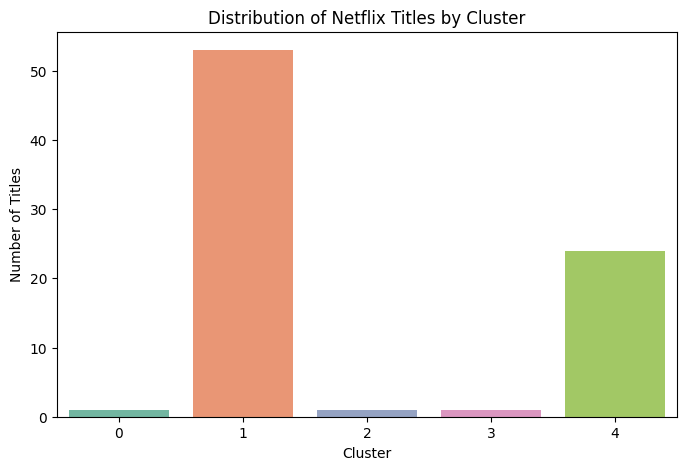

In [4]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score
# Load dataset
df = pd.read_csv('/content/archive (4).zip')  # You can get this dataset from Kaggle

# Drop rows with missing genres
df = df.dropna(subset=['lister-item-header'])

# Preprocess genres
df['genres'] = df['lister-item-header'].apply(lambda x: [genre.strip() for genre in x.split(',')])
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genres'])

# Apply KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(genre_matrix)

# Add cluster labels to the dataframe
df['Cluster'] = clusters
silhouette_avg = silhouette_score(genre_matrix, clusters)
print('Silhouette Score:', silhouette_avg)

db_index = davies_bouldin_score(genre_matrix, clusters)
print('Davies-Bouldin Index:', db_index)
# Visualize cluster distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Cluster', data=df, palette='Set2')
plt.title('Distribution of Netflix Titles by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Titles')
plt.show()

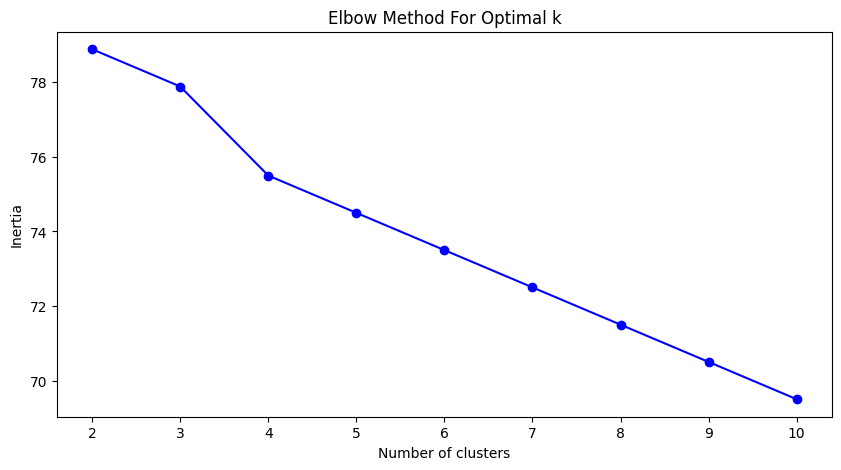

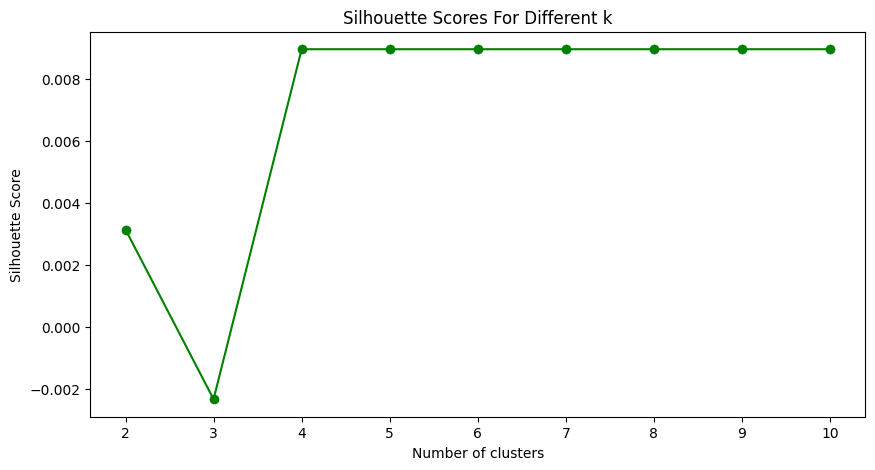


=== Cluster Evaluation Metrics (k=5) ===
Silhouette Score: 0.0089
Davies-Bouldin Index: 1.1235
Calinski-Harabasz Index: 1.3748

Cluster Sizes:
0     1
1     1
2    75
3     1
4     2
Name: count, dtype: int64

Average Intra-Cluster Distance: 0.2473


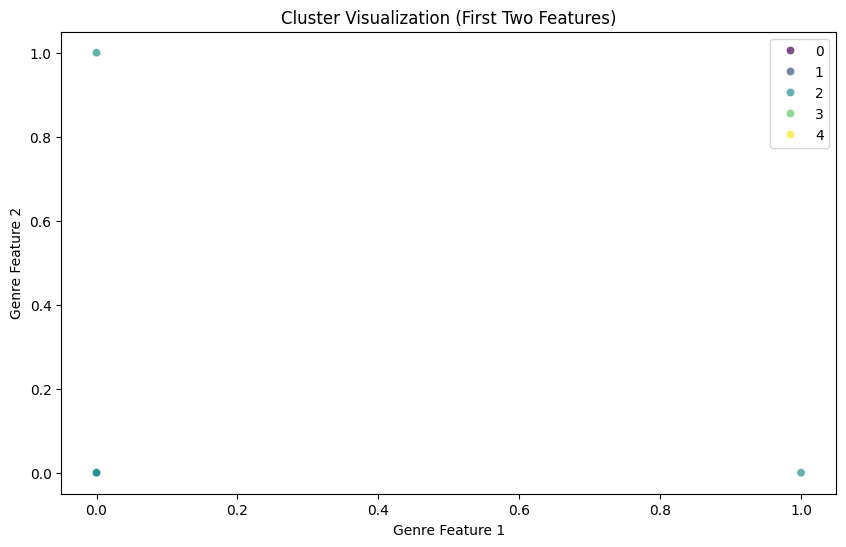

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score,
                            davies_bouldin_score,
                            calinski_harabasz_score,
                            adjusted_rand_score)
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/archive (4).zip')

# Data preprocessing
df = df.dropna(subset=['lister-item-header'])
df['genres'] = df['lister-item-header'].apply(lambda x: [genre.strip() for genre in x.split(',')])
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genres'])

# KMeans clustering with elbow method for optimal k
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(genre_matrix)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(genre_matrix, clusters))

# Plot elbow curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Plot silhouette scores
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouettes, 'go-')
plt.title('Silhouette Scores For Different k')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

# Final clustering with optimal k (choose based on plots)
optimal_k = 5  # Change this based on your elbow/silhouette analysis
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(genre_matrix)
df['Cluster'] = clusters

# Comprehensive evaluation metrics
def evaluate_clusters(X, labels):
    print(f"\n=== Cluster Evaluation Metrics (k={optimal_k}) ===")
    print(f"Silhouette Score: {silhouette_score(X, labels):.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_score(X, labels):.4f}")
    print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X, labels):.4f}")

    # Cluster statistics
    print("\nCluster Sizes:")
    print(pd.Series(labels).value_counts().sort_index())

    # Intra-cluster distances
    centroids = kmeans.cluster_centers_
    intra_cluster_dist = []
    for i in range(optimal_k):
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:  # Avoid division by zero
            dist = np.mean(np.sum((cluster_points - centroids[i])**2, axis=1))
            intra_cluster_dist.append(dist)
    print(f"\nAverage Intra-Cluster Distance: {np.mean(intra_cluster_dist):.4f}")

evaluate_clusters(genre_matrix, clusters)

# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=genre_matrix[:, 0],
    y=genre_matrix[:, 1],
    hue=clusters,
    palette='viridis',
    alpha=0.7
)
plt.title('Cluster Visualization (First Two Features)')
plt.xlabel('Genre Feature 1')
plt.ylabel('Genre Feature 2')
plt.show()


In [5]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering # Import AgglomerativeClustering
from sklearn.metrics import (silhouette_score,
                            davies_bouldin_score,
                            calinski_harabasz_score) # Import necessary metrics
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse # Import to check if matrix is sparse

# Data preprocessing (same as before)
df = pd.read_csv('/content/archive (4).zip')
df = df.dropna(subset=['lister-item-header'])
# Combine genres into a single string for TF-IDF
df['genres_str'] = df['lister-item-header'].apply(lambda x: ', '.join([genre.strip() for genre in x.split(',')]))


# --- Using TF-IDF Vectorization ---
tfidf_vectorizer = TfidfVectorizer()
genre_matrix_tfidf = tfidf_vectorizer.fit_transform(df['genres_str'])
print(f"TF-IDF matrix shape: {genre_matrix_tfidf.shape}") # Likely a sparse matrix

# Decide which matrix to use for clustering - now you have genre_matrix (binary) and genre_matrix_tfidf
X_cluster_tfidf = genre_matrix_tfidf

# --- Run KMeans on TF-IDF data and evaluate ---
# Repeat the k_range loop and evaluation using X_cluster_tfidf
# Example for k=5:
optimal_k_example = 5 # Choose based on your analysis of plots
kmeans_tfidf = KMeans(n_clusters=optimal_k_example, random_state=42, n_init=10)
clusters_tfidf = kmeans_tfidf.fit_predict(X_cluster_tfidf)
df['Cluster_KMeans_TFIDF'] = clusters_tfidf

print("\nEvaluation for KMeans on TF-IDF data:")
# Assuming evaluate_clusters function is defined in a previous cell and accessible
# If not, you need to redefine it or ensure it's in the same cell or a shared module.
# Adding a placeholder definition here based on the previous cell's code for completeness.
def evaluate_clusters(X, labels, algorithm_name=""):
    print(f"\n=== Cluster Evaluation Metrics {algorithm_name} (k={len(np.unique(labels))}) ===")

    # Convert sparse matrix to dense array for metrics that require it
    X_dense = X.toarray() if issparse(X) else X

    if len(np.unique(labels)) > 1: # Metrics require more than one cluster
        # silhouette_score can handle sparse matrices, but others cannot
        print(f"Silhouette Score: {silhouette_score(X, labels):.4f}") # Use original X here
        print(f"Davies-Bouldin Index: {davies_bouldin_score(X_dense, labels):.4f}") # Use dense X_dense here
        print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_dense, labels):.4f}") # Use dense X_dense here
    else:
         print("Metrics require more than one cluster.")


    # Cluster statistics
    print("\nCluster Sizes:")
    print(pd.Series(labels).value_counts().sort_index())

    # Intra-cluster distances (This requires the kmeans object, which is not passed)
    # To properly calculate this, you would need to pass the fitted kmeans object
    # or compute centroids differently for Agglomerative.
    # Skipping intra-cluster distance calculation in this generic function for now.
    # If needed, pass the model object or centroids to this function.
    # For KMeans: centroids = model.cluster_centers_
    # For Agglomerative, you might need to calculate them manually.


evaluate_clusters(X_cluster_tfidf, clusters_tfidf, algorithm_name=f"(KMeans TF-IDF)")


# --- Consider Agglomerative Clustering on TF-IDF data with Jaccard distance ---
# Note: Jaccard distance is often better for sparse binary/count data,
# but TF-IDF is float. Euclidean is common for TF-IDF.
# Let's stick with Euclidean for TF-IDF for simplicity here,
# but keep distance metric in mind for other data types or algorithms.

# Example for k=5 with Agglomerative on TF-IDF
agg_tfidf = AgglomerativeClustering(n_clusters=optimal_k_example)
# Agglomerative needs dense matrix - using toarray()
# Note: For very large sparse matrices, converting to dense might consume too much memory.
# Consider algorithms that can handle sparse data directly if memory is an issue.
clusters_agg_tfidf = agg_tfidf.fit_predict(X_cluster_tfidf.toarray())
df['Cluster_Agg_TFIDF'] = clusters_agg_tfidf

print("\nEvaluation for Agglomerative on TF-IDF data:")
# Pass the dense array for evaluation metrics if the metric function expects it
evaluate_clusters(X_cluster_tfidf.toarray(), clusters_agg_tfidf, algorithm_name=f"(Agglomerative TF-IDF)")

# Remember to repeat the k-selection process (plotting silhouettes/DB) for each new approach (TF-IDF + KMeans, TF-IDF + Agglomerative, etc.)
# before settling on a final optimal_k.

TF-IDF matrix shape: (80, 141)

Evaluation for KMeans on TF-IDF data:

=== Cluster Evaluation Metrics (KMeans TF-IDF) (k=5) ===
Silhouette Score: 0.0433
Davies-Bouldin Index: 2.7640
Calinski-Harabasz Index: 2.1598

Cluster Sizes:
0    16
1     6
2     2
3    54
4     2
Name: count, dtype: int64

Evaluation for Agglomerative on TF-IDF data:

=== Cluster Evaluation Metrics (Agglomerative TF-IDF) (k=5) ===
Silhouette Score: 0.0419
Davies-Bouldin Index: 2.7688
Calinski-Harabasz Index: 2.1134

Cluster Sizes:
0    15
1    55
2     6
3     2
4     2
Name: count, dtype: int64
